#LOW Volatility + Momentum

##Loading S&P 500 His Data

In [ ]:
import os
import pandas as pd

search_filename = 'sp500_historical_data_2002_2024.csv'
found_path = None

print("Searching for the file in your Google Drive...")
for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    if search_filename in files:
        found_path = os.path.join(root, search_filename)
        print(f"Found file at: {found_path}")
        break

if not found_path:
    print("File not found. Please double-check the file name or ensure it's in the Drive you mounted.")
else:
    print("\nLoading data...")
    # Read the CSV without specifying the date column yet to check column names
    df = pd.read_csv(found_path)
    print("\nColumns in the dataset:")
    print(df.columns.tolist())
    print("\nLast 10 rows of the DataFrame:")
    display(df.tail(10))

Searching for the file in your Google Drive...
Found file at: /content/drive/MyDrive/Colab Notebooks/Quant Strategy/sp500_historical_data_2002_2024.csv

Loading data...

Columns in the dataset:
['date', 'ticker', 'company_name', 'open', 'high', 'low', 'close', 'adj_close', 'volume']

Last 10 rows of the DataFrame:


,date,ticker,company_name,open,high,low,close,adj_close,volume
2831371,2024-05-17,UNH,UNITEDHEALTH GROUP INC,522.94000,525.84998,520.01001,524.63000,524.63000,2657396.0
2831372,2024-05-20,UNH,UNITEDHEALTH GROUP INC,524.63000,524.63000,516.53998,517.22998,517.22998,2476393.0
2831373,2024-05-21,UNH,UNITEDHEALTH GROUP INC,518.32001,524.71997,515.91998,523.54999,523.54999,2521986.0
2831374,2024-05-22,UNH,UNITEDHEALTH GROUP INC,522.82001,526.28003,520.65002,521.34998,521.34998,2299273.0
2831375,2024-05-23,UNH,UNITEDHEALTH GROUP INC,518.32001,520.22498,515.22998,516.83002,516.83002,3055555.0
2831376,2024-05-24,UNH,UNITEDHEALTH GROUP INC,516.10999,517.14001,507.51999,508.17001,508.17001,2528228.0
2831377,2024-05-28,UNH,UNITEDHEALTH GROUP INC,506.64999,506.64999,501.89999,503.67999,503.67999,2912992.0
2831378,2024-05-29,UNH,UNITEDHEALTH GROUP INC,492.34000,493.89999,473.26999,484.72000,484.72000,7521587.0
2831379,2024-05-30,UNH,UNITEDHEALTH GROUP INC,482.32001,486.03000,478.00000,481.64999,481.64999,5170507.0
2831380,2024-05-31,UNH,UNITEDHEALTH GROUP INC,482.41000,498.41000,482.41000,495.37000,495.37000,6694985.0


## Prepare data

In [ ]:
import numpy as np

print("Formatting dates and sorting...")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

print("Calculating daily returns...")
# Added fill_method=None to resolve FutureWarning
df['daily_return'] = df.groupby('ticker')['adj_close'].pct_change(fill_method=None)

print("Calculating 1-year momentum (252 trading days) and Volatility...")
# Momentum: 1-year return
df['momentum'] = df.groupby('ticker')['adj_close'].transform(lambda x: x.pct_change(periods=252, fill_method=None))

# Volatility: Annualized standard deviation of daily returns over the last 252 days
df['volatility'] = df.groupby('ticker')['daily_return'].transform(
    lambda x: x.rolling(window=252, min_periods=126).std() * np.sqrt(252)
)

print("Extracting month-end data for rebalancing...")
# Create a Year-Month column
df['year_month'] = df['date'].dt.to_period('M')

# Keep only the last trading day of each month for each ticker
monthly_df = df.groupby(['ticker', 'year_month']).tail(1).copy()

# Drop rows where we don't have enough data to calculate momentum or volatility
monthly_df = monthly_df.dropna(subset=['momentum', 'volatility'])

print("Data preparation complete! Total month-end records available:", len(monthly_df))

Formatting dates and sorting...
Calculating daily returns...
Calculating 1-year momentum (252 trading days) and Volatility...
Extracting month-end data for rebalancing...
Data preparation complete! Total month-end records available: 123273


##Strategy 1:Top 30% Momentum & Bottom 50% Volatility

In [ ]:
print("Step 1: Selecting Top 30% Momentum stocks each month...")
# Rank momentum cross-sectionally for each month (higher rank = higher momentum)
monthly_df['mom_rank_pct'] = monthly_df.groupby('year_month')['momentum'].rank(pct=True)
top_30_mom = monthly_df[monthly_df['mom_rank_pct'] >= 0.70].copy()

print("Step 2: Ignoring Top 50% Volatility from the Top Momentum stocks ")
# Rank volatility cross-sectionally within the Step 1 universe (lower rank = lower volatility)
top_30_mom['vol_rank_pct'] = top_30_mom.groupby('year_month')['volatility'].rank(pct=True)
target_portfolio = top_30_mom[top_30_mom['vol_rank_pct'] <= 0.50].copy()

print("\nStrategy Selection Complete!")
print(f"Average number of stocks in the portfolio per month: {target_portfolio.groupby('year_month').size().mean():.1f}")

print("\nSample Target Portfolio (Most recent month):")
recent_month = target_portfolio['year_month'].max()
recent_portfolio = target_portfolio[target_portfolio['year_month'] == recent_month]
display(recent_portfolio[['date', 'ticker', 'company_name', 'momentum', 'volatility']].head(10))

Step 1: Selecting Top 30% Momentum stocks each month...
Step 2: Ignoring Top 50% Volatility from the Top Momentum stocks 

Strategy Selection Complete!
Average number of stocks in the portfolio per month: 72.0

Sample Target Portfolio (Most recent month):


,date,ticker,company_name,momentum,volatility
43112,2024-05-31,ACGL,ARCH CAPITAL GROUP LTD NEW,0.472453,0.224016
108617,2024-05-31,AFL,AFLAC INC,0.399626,0.192524
119961,2024-05-31,AIG,AMERICAN INTERNATIONAL GROUP INC,0.491955,0.177779
128757,2024-05-31,AIZ,ASSURANT INC,0.445704,0.226226
147333,2024-05-31,ALL,ALLSTATE CORP,0.544675,0.225938
178859,2024-05-31,AMGN,AMGEN INC,0.386132,0.250413
183556,2024-05-31,AMP,AMERIPRISE FINANCIAL INC,0.462827,0.176523
233712,2024-05-31,APH,AMPHENOL CORP NEW,0.754407,0.175277
273752,2024-05-31,AVY,AVERY DENNISON CORP,0.412462,0.184689
284195,2024-05-31,AXP,AMERICAN EXPRESS CO,0.513623,0.214932


Fetching S&P 500 benchmark data...

=== Performance Metrics ===
----------------------------------------
Metric		Strategy	Benchmark
----------------------------------------
Ann. Return	8.63%		10.18%
Ann. Volatility	12.89%		14.73%
Sharpe Ratio	0.51		0.55
Max Drawdown	-41.67%		-52.56%
----------------------------------------


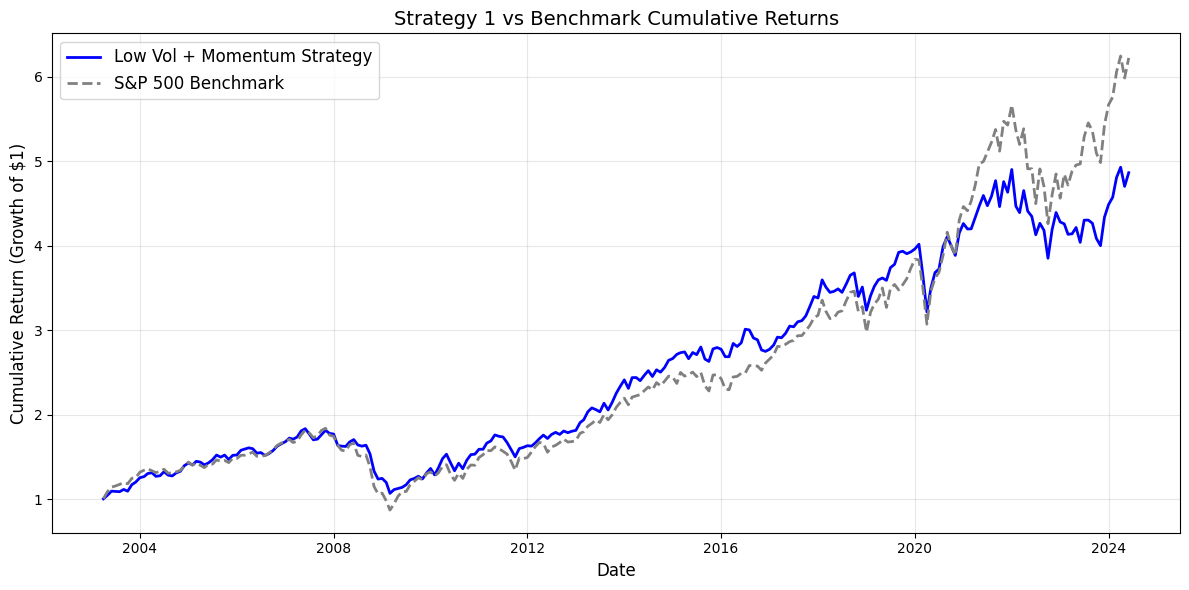

In [ ]:
print("Fetching S&P 500 benchmark data...")
start_date = port_returns.index.min().strftime('%Y-%m-%d')
end_date = port_returns.index.max().strftime('%Y-%m-%d')

spy = yf.download('^GSPC', start=start_date, end=end_date, progress=False)
# Calculate monthly returns for S&P 500. Use 'Close' instead of 'Adj Close'.
spy_monthly = spy['Close'].resample('M').last().pct_change().dropna()
# If the result is a DataFrame (due to multi-index columns), squeeze it to a Series
if isinstance(spy_monthly, pd.DataFrame):
    spy_monthly = spy_monthly.squeeze()
spy_monthly.name = 'benchmark_return'

# Convert indices to monthly periods to avoid timestamp mismatch during join
# Only convert if the index is not already a PeriodIndex
if not isinstance(port_returns.index, pd.PeriodIndex):
    port_returns.index = port_returns.index.to_period('M')
if not isinstance(spy_monthly.index, pd.PeriodIndex):
    spy_monthly.index = spy_monthly.index.to_period('M')

# Merge strategy and benchmark returns
results = port_returns.join(spy_monthly, how='inner')

# Convert index back to timestamp for plotting
results.index = results.index.to_timestamp(how='end')

# Calculate Cumulative Returns
results['Strategy Cumulative'] = (1 + results['strategy_return']).cumprod()
results['Benchmark Cumulative'] = (1 + results['benchmark_return']).cumprod()

# Calculate Metrics (Annualized)
# Assuming 12 months in a year
risk_free_rate = 0.02 # Assuming 2% annual risk-free rate for Sharpe calculation
monthly_rf = (1 + risk_free_rate)**(1/12) - 1

def calc_metrics(returns):
    ann_return = (1 + returns.mean())**12 - 1
    ann_vol = returns.std() * np.sqrt(12)
    sharpe = (ann_return - risk_free_rate) / ann_vol

    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()

    return ann_return, ann_vol, sharpe, max_dd

strat_metrics = calc_metrics(results['strategy_return'])
bench_metrics = calc_metrics(results['benchmark_return'])

print("\n=== Performance Metrics ===")
print(f"{'-'*40}")
print(f"Metric\t\tStrategy\tBenchmark")
print(f"{'-'*40}")
print(f"Ann. Return\t{strat_metrics[0]:.2%}\t\t{bench_metrics[0]:.2%}")
print(f"Ann. Volatility\t{strat_metrics[1]:.2%}\t\t{bench_metrics[1]:.2%}")
print(f"Sharpe Ratio\t{strat_metrics[2]:.2f}\t\t{bench_metrics[2]:.2f}")
print(f"Max Drawdown\t{strat_metrics[3]:.2%}\t\t{bench_metrics[3]:.2%}")
print(f"{'-'*40}")

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(results.index, results['Strategy Cumulative'], label='Low Vol + Momentum Strategy', color='blue', linewidth=2)
plt.plot(results.index, results['Benchmark Cumulative'], label='S&P 500 Benchmark', color='gray', linestyle='--', linewidth=2)

plt.title('Strategy 1 vs Benchmark Cumulative Returns', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (Growth of $1)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("Calculating yearly performance metrics...")

# Create a list to store yearly metrics
yearly_metrics = []

# Group results by year
results['year'] = results.index.year
grouped = results.groupby('year')

rf = 0.02 # 2% risk-free rate

for year, group in grouped:
    # Since we have monthly returns, we compound them for the exact yearly return
    strat_ret = (1 + group['strategy_return']).prod() - 1
    strat_vol = group['strategy_return'].std() * np.sqrt(12)
    strat_sharpe = (strat_ret - rf) / strat_vol if strat_vol != 0 else np.nan

    bench_ret = (1 + group['benchmark_return']).prod() - 1
    bench_vol = group['benchmark_return'].std() * np.sqrt(12)
    bench_sharpe = (bench_ret - rf) / bench_vol if bench_vol != 0 else np.nan

    yearly_metrics.append({
        'Year': year,
        'Strat Return': strat_ret,
        'Bench Return': bench_ret,
        'Strat Volatility': strat_vol,
        'Bench Volatility': bench_vol,
        'Strat Sharpe': strat_sharpe,
        'Bench Sharpe': bench_sharpe
    })

yearly_df = pd.DataFrame(yearly_metrics).set_index('Year')

# Format the dataframe for display
format_dict = {
    'Strat Return': '{:.2%}',
    'Bench Return': '{:.2%}',
    'Strat Volatility': '{:.2%}',
    'Bench Volatility': '{:.2%}',
    'Strat Sharpe': '{:.2f}',
    'Bench Sharpe': '{:.2f}'
}

# Display with some background gradients for easier reading
styled_yearly_df = yearly_df.style.format(format_dict).background_gradient(
    cmap='RdYlGn',
    subset=['Strat Return', 'Bench Return', 'Strat Sharpe', 'Bench Sharpe']
)

display(styled_yearly_df)

Calculating yearly performance metrics...


,Strat Return,Bench Return,Strat Volatility,Bench Volatility,Strat Sharpe,Bench Sharpe
Year,,,,,,
2003,25.65%,32.19%,9.55%,10.01%,2.48,3.02
2004,13.82%,8.99%,8.71%,7.25%,1.36,0.96
2005,6.62%,3.00%,8.52%,7.81%,0.54,0.13
2006,10.24%,13.62%,7.14%,5.70%,1.15,2.04
2007,5.46%,3.53%,9.10%,9.69%,0.38,0.16
2008,-29.62%,-38.49%,16.86%,20.99%,-1.88,-1.93
2009,9.46%,23.45%,15.94%,22.31%,0.47,0.96
2010,16.62%,12.78%,19.96%,19.31%,0.73,0.56
2011,2.65%,-0.00%,12.93%,15.97%,0.05,-0.13


In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Calculating strategy returns...")
# Calculate monthly returns for all stocks
monthly_prices = df.groupby(['ticker', 'year_month'])['adj_close'].last().reset_index()
monthly_prices['monthly_return'] = monthly_prices.groupby('ticker')['adj_close'].pct_change()

# The portfolio selected at the end of month T earns the return of month T+1
target_portfolio['next_month'] = target_portfolio['year_month'] + 1

# Merge portfolio holdings with the next month's returns
strategy_returns = pd.merge(
    target_portfolio[['ticker', 'next_month']],
    monthly_prices[['ticker', 'year_month', 'monthly_return']],
    left_on=['ticker', 'next_month'],
    right_on=['ticker', 'year_month'],
    how='inner'
)

# Calculate equal-weighted strategy return per month
port_returns = strategy_returns.groupby('year_month')['monthly_return'].mean().reset_index()
port_returns.rename(columns={'monthly_return': 'strategy_return'}, inplace=True)

# Convert period to timestamp for plotting
port_returns['date'] = port_returns['year_month'].dt.to_timestamp(how='end')
port_returns.set_index('date', inplace=True)
port_returns.drop(columns=['year_month'], inplace=True)

print("Strategy returns calculated.")
display(port_returns.head())

Calculating strategy returns...
Strategy returns calculated.


,strategy_return
date,
2003-02-28 23:59:59.999999999,-0.011055
2003-03-31 23:59:59.999999999,0.005764
2003-04-30 23:59:59.999999999,0.042064
2003-05-31 23:59:59.999999999,0.046766
2003-06-30 23:59:59.999999999,-0.002875


## Summary of Strategy 1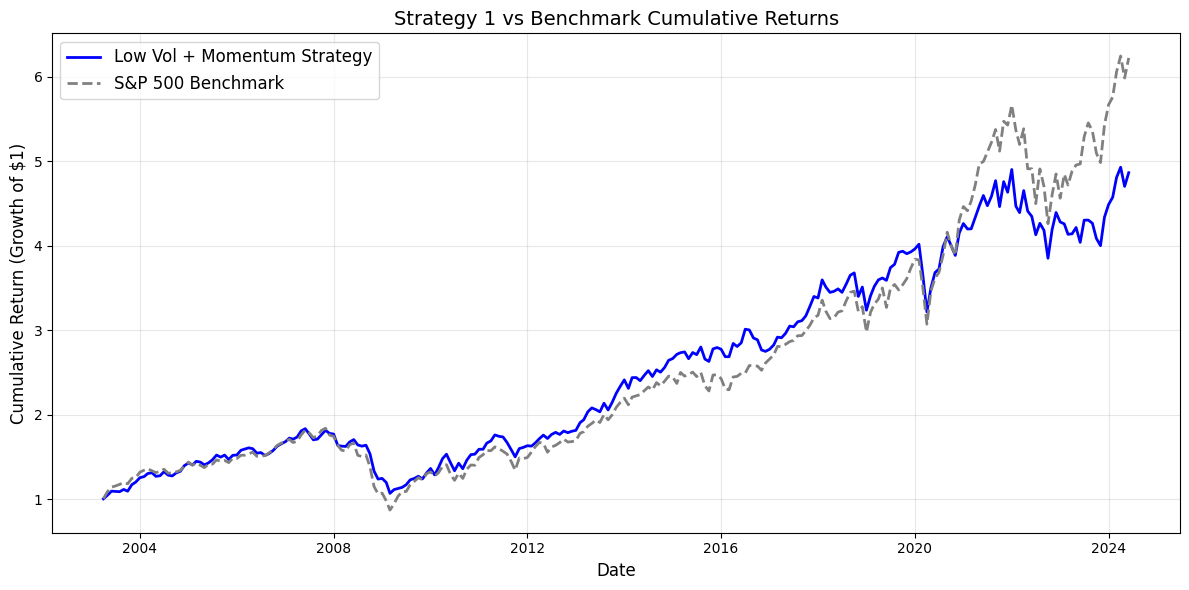

## Strategy2: Top 30% Momentum, Bottom 80% Volatility




In [ ]:
print("Step 1: Selecting Top 30% Momentum stocks each month...")
top_30_mom_v2 = monthly_df[monthly_df['mom_rank_pct'] >= 0.70].copy()

print("Step 2: Ignoring Top 20% Volatility from the Top Momentum stocks (Keeping lowest 80%)...")
top_30_mom_v2['vol_rank_pct'] = top_30_mom_v2.groupby('year_month')['volatility'].rank(pct=True)
target_portfolio_v2 = top_30_mom_v2[top_30_mom_v2['vol_rank_pct'] <= 0.80].copy()

print("\nAlternative Strategy Selection Complete!")
print(f"Average number of stocks in this portfolio per month: {target_portfolio_v2.groupby('year_month').size().mean():.1f}")

Step 1: Selecting Top 30% Momentum stocks each month...
Step 2: Ignoring Top 20% Volatility from the Top Momentum stocks (Keeping lowest 80%)...

Alternative Strategy Selection Complete!
Average number of stocks in this portfolio per month: 115.1


Calculating alternative strategy returns...

=== Performance Metrics (Alternative Strategy) ===
----------------------------------------
Metric		Strategy v2	Benchmark
----------------------------------------
Ann. Return	9.70%		10.18%
Ann. Volatility	13.88%		14.73%
Sharpe Ratio	0.55		0.55
Max Drawdown	-43.80%		-52.56%
----------------------------------------


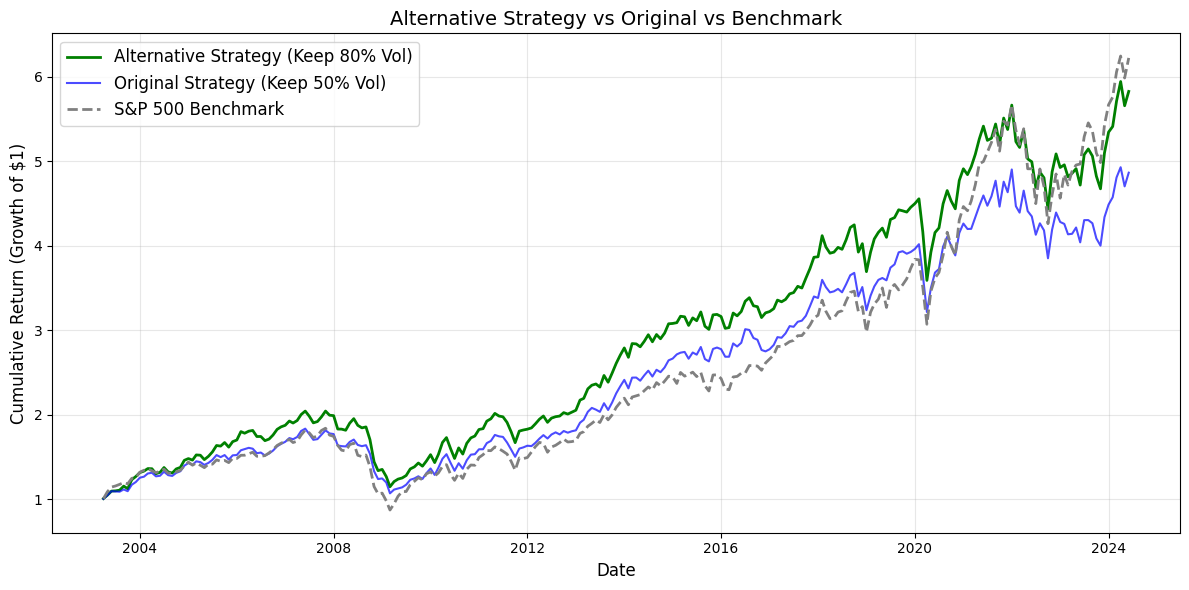

In [ ]:
print("Calculating alternative strategy returns...")

target_portfolio_v2['next_month'] = target_portfolio_v2['year_month'] + 1

# Merge portfolio holdings with the next month's returns
strategy_returns_v2 = pd.merge(
    target_portfolio_v2[['ticker', 'next_month']],
    monthly_prices[['ticker', 'year_month', 'monthly_return']],
    left_on=['ticker', 'next_month'],
    right_on=['ticker', 'year_month'],
    how='inner'
)

# Calculate equal-weighted strategy return per month
port_returns_v2 = strategy_returns_v2.groupby('year_month')['monthly_return'].mean().reset_index()
port_returns_v2.rename(columns={'monthly_return': 'strategy_return_v2'}, inplace=True)
port_returns_v2.set_index('year_month', inplace=True)

# Merge with benchmark
results_v2 = port_returns_v2.join(spy_monthly, how='inner')
results_v2.index = results_v2.index.to_timestamp(how='end')

# Calculate Cumulative Returns
results_v2['Strategy v2 Cumulative'] = (1 + results_v2['strategy_return_v2']).cumprod()
results_v2['Benchmark Cumulative'] = (1 + results_v2['benchmark_return']).cumprod()

strat_metrics_v2 = calc_metrics(results_v2['strategy_return_v2'])

print("\n=== Performance Metrics (Alternative Strategy) ===")
print(f"{'-'*40}")
print(f"Metric\t\tStrategy v2\tBenchmark")
print(f"{'-'*40}")
print(f"Ann. Return\t{strat_metrics_v2[0]:.2%}\t\t{bench_metrics[0]:.2%}")
print(f"Ann. Volatility\t{strat_metrics_v2[1]:.2%}\t\t{bench_metrics[1]:.2%}")
print(f"Sharpe Ratio\t{strat_metrics_v2[2]:.2f}\t\t{bench_metrics[2]:.2f}")
print(f"Max Drawdown\t{strat_metrics_v2[3]:.2%}\t\t{bench_metrics[3]:.2%}")
print(f"{'-'*40}")

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(results_v2.index, results_v2['Strategy v2 Cumulative'], label='Alternative Strategy (Keep 80% Vol)', color='green', linewidth=2)
plt.plot(results.index, results['Strategy Cumulative'], label='Original Strategy (Keep 50% Vol)', color='blue', linewidth=1.5, alpha=0.7)
plt.plot(results_v2.index, results_v2['Benchmark Cumulative'], label='S&P 500 Benchmark', color='gray', linestyle='--', linewidth=2)

plt.title('Alternative Strategy vs Original vs Benchmark', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (Growth of $1)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plotting Annual Returns...


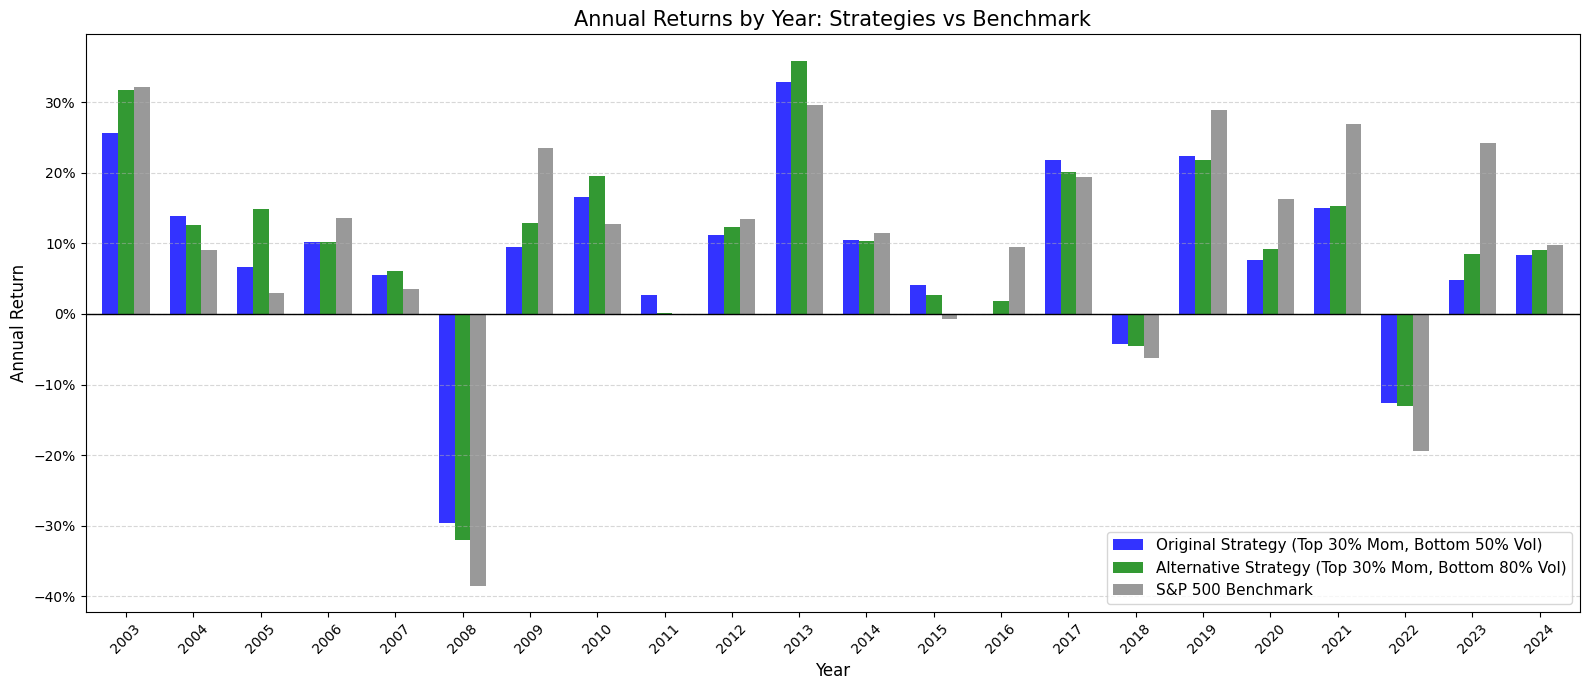

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

print("Plotting Annual Returns...")

# Extract just the return columns for the plot
yearly_returns_df = yearly_df[['Strat1 (50% Vol) Return', 'Strat2 (80% Vol) Return', 'Bench Return']]

# Create a grouped bar chart
ax = yearly_returns_df.plot(
    kind='bar',
    figsize=(16, 7),
    color=['blue', 'green', 'gray'],
    alpha=0.8,
    width=0.7
)

plt.title('Annual Returns by Year: Strategies vs Benchmark', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Annual Return', fontsize=12)
plt.legend(['Original Strategy (Top 30% Mom, Bottom 50% Vol)',
            'Alternative Strategy (Top 30% Mom, Bottom 80% Vol)',
            'S&P 500 Benchmark'],
           fontsize=11)

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=1) # Add a solid line at 0%
plt.tight_layout()
plt.show()

In [ ]:
print("Calculating yearly performance metrics for both strategies...")

# Create a list to store yearly metrics
yearly_metrics = []

# Combine results into a single DataFrame for easier grouping
combined_results = results[['strategy_return', 'benchmark_return']].copy()
combined_results['strategy_return_v2'] = results_v2['strategy_return_v2']
combined_results['year'] = combined_results.index.year

grouped = combined_results.groupby('year')
rf = 0.02 # 2% risk-free rate

for year, group in grouped:
    # Original Strategy (Top 30% Mom & Bottom 50% Vol)
    strat_ret = (1 + group['strategy_return']).prod() - 1
    strat_vol = group['strategy_return'].std() * np.sqrt(12)
    strat_sharpe = (strat_ret - rf) / strat_vol if strat_vol != 0 else np.nan

    # Alternative Strategy (Top 30% Mom & Bottom 80% Vol)
    strat2_ret = (1 + group['strategy_return_v2']).prod() - 1
    strat2_vol = group['strategy_return_v2'].std() * np.sqrt(12)
    strat2_sharpe = (strat2_ret - rf) / strat2_vol if strat2_vol != 0 else np.nan

    # Benchmark
    bench_ret = (1 + group['benchmark_return']).prod() - 1
    bench_vol = group['benchmark_return'].std() * np.sqrt(12)
    bench_sharpe = (bench_ret - rf) / bench_vol if bench_vol != 0 else np.nan

    yearly_metrics.append({
        'Year': year,
        'Strat1 (50% Vol) Return': strat_ret,
        'Strat2 (80% Vol) Return': strat2_ret,
        'Bench Return': bench_ret,
        'Strat1 Volatility': strat_vol,
        'Strat2 Volatility': strat2_vol,
        'Bench Volatility': bench_vol,
        'Strat1 Sharpe': strat_sharpe,
        'Strat2 Sharpe': strat2_sharpe,
        'Bench Sharpe': bench_sharpe
    })

yearly_df = pd.DataFrame(yearly_metrics).set_index('Year')

# Format the dataframe for display dynamically
format_dict = {
    col: '{:.2%}' if 'Return' in col or 'Volatility' in col else '{:.2f}'
    for col in yearly_df.columns
}

# Define the columns to apply the color gradient to
gradient_cols = [c for c in yearly_df.columns if 'Return' in c or 'Sharpe' in c]

# Display with background gradients
styled_yearly_df = yearly_df.style.format(format_dict).background_gradient(
    cmap='RdYlGn',
    subset=gradient_cols
)

display(styled_yearly_df)


Calculating yearly performance metrics for both strategies...


,Strat1 (50% Vol) Return,Strat2 (80% Vol) Return,Bench Return,Strat1 Volatility,Strat2 Volatility,Bench Volatility,Strat1 Sharpe,Strat2 Sharpe,Bench Sharpe
Year,,,,,,,,,
2003,25.65%,31.70%,32.19%,9.55%,11.29%,10.01%,2.48,2.63,3.02
2004,13.82%,12.59%,8.99%,8.71%,10.56%,7.25%,1.36,1.00,0.96
2005,6.62%,14.80%,3.00%,8.52%,9.98%,7.81%,0.54,1.28,0.13
2006,10.24%,10.23%,13.62%,7.14%,9.33%,5.70%,1.15,0.88,2.04
2007,5.46%,6.09%,3.53%,9.10%,9.16%,9.69%,0.38,0.45,0.16
2008,-29.62%,-31.96%,-38.49%,16.86%,19.80%,20.99%,-1.88,-1.72,-1.93
2009,9.46%,12.88%,23.45%,15.94%,16.79%,22.31%,0.47,0.65,0.96
2010,16.62%,19.50%,12.78%,19.96%,22.23%,19.31%,0.73,0.79,0.56
2011,2.65%,0.19%,-0.00%,12.93%,14.89%,15.97%,0.05,-0.12,-0.13


In [ ]:
print("Calculating Cumulative Returns up to the end of each year...")

# Calculate the running cumulative return for the entire period
combined_results['strat1_cum'] = (1 + combined_results['strategy_return']).cumprod() - 1
combined_results['strat2_cum'] = (1 + combined_results['strategy_return_v2']).cumprod() - 1
combined_results['bench_cum'] = (1 + combined_results['benchmark_return']).cumprod() - 1

# Group by year and take the last value of each year (which represents the total cumulative return up to that point)
yearly_cum_df = combined_results.groupby('year')[['strat1_cum', 'strat2_cum', 'bench_cum']].last()

# Rename columns for clarity
yearly_cum_df.columns = [
    'Strat1 (50% Vol) Cumulative',
    'Strat2 (80% Vol) Cumulative',
    'Benchmark Cumulative'
]

# Calculate the difference between Benchmark and Strategy 2
yearly_cum_df['Difference (Benchmark - Strat2)'] = yearly_cum_df['Benchmark Cumulative'] - yearly_cum_df['Strat2 (80% Vol) Cumulative']

# Format the dataframe for display
format_dict_cum = {col: '{:.2%}' for col in yearly_cum_df.columns}

# Display with background gradients
styled_yearly_cum_df = yearly_cum_df.style.format(format_dict_cum).background_gradient(
    cmap='RdYlGn'
)


display(styled_yearly_cum_df)


Calculating Cumulative Returns up to the end of each year...


,Strat1 (50% Vol) Cumulative,Strat2 (80% Vol) Cumulative,Benchmark Cumulative,Difference (Benchmark - Strat2)
year,,,,
2003,25.65%,31.70%,32.19%,0.49%
2004,43.02%,48.28%,44.08%,-4.20%
2005,52.49%,70.22%,48.40%,-21.82%
2006,68.10%,87.63%,68.61%,-19.02%
2007,77.28%,99.07%,74.57%,-24.51%
2008,24.77%,35.45%,7.38%,-28.06%
2009,36.58%,52.89%,32.57%,-20.33%
2010,59.27%,82.71%,49.51%,-33.19%
2011,63.49%,83.05%,49.51%,-33.54%


##Summary of Star 2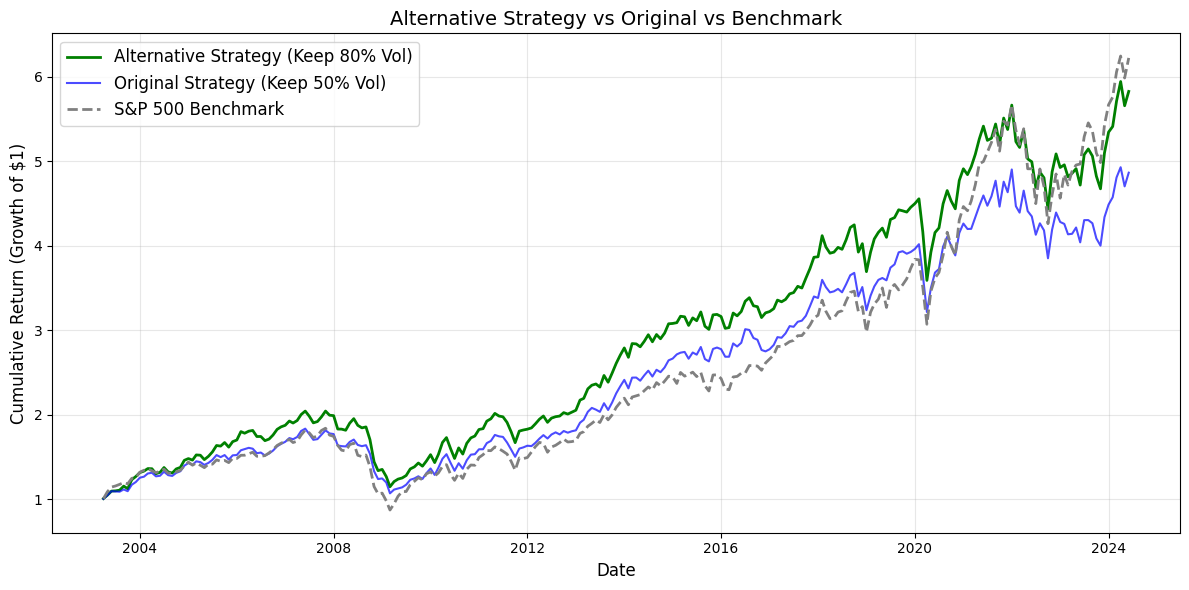